# INSIGHT 심화세션 사전과제
## 04. 딥러닝 2

## <span style="background-color:#F993C0; color:#311d26; padding:4px; border-radius:0px;"> RNN의 한계 </span>

#### <span style="background-color:#633a4c; color:#fde9f2; padding:4px; border-radius:0px;"> Attention의 등장 배경 및 장점  </span>

#### 장기 의존성 문제 & Vanishing gradient

RNN 모델에서 문장과 같은 데이터가 길어질수록, 데이터의 후반부에서 초반에 위치한 정보가 잘 반영이 되지 않는 문제가 발생

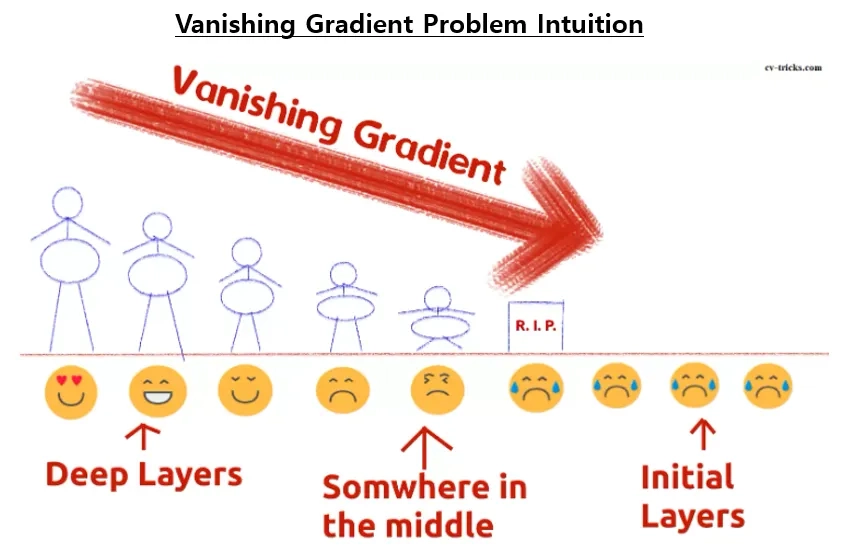

문장이 길어지면 길어질수록, 곱해지는 가중치의 횟수가 늘어남에 따라 두가지 문제점이 발생
- 계산 값이 발산한다 → Exploding gradient
- 계산 값이 0이 된다 → Vanishing grandient 

#### Attention의 등장 배경 : Seq2Seq의 병목 현상

- 기존 Seq2Seq 모델은 입력 문장의 모든 정보를 하나의 고정된 Context Vector에 압축
- 입력 문장이 길어질수록 하나의 벡터에 모든 정보를 담기 어려워지고, 중요한 정보가 손실되는 문제가 발생
- Decoder는 매번 같은 Context Vector만 참고하기 때문에, 출력 단어마다 필요한 정보를 다르게 반영하기 어려움

-> Attention은 Decoder가 단어를 생성할 때마다 입력 문장 전체를 다시 보고, 현재 단어와 관련 있는 부분에 더 집중하여 새로운 Context Vector를 만든다!

Attention은 말 그대로 중요한 정보에 더 집중하는 메커니즘
-> 결과를 만들 때 입력값의 모든 부분을 똑같이 참고하는 것이 아니라, 현재 시점에서 가장 중요한 부분에 더 높은 가중치를 부여하여 활용!

#### Seq2Seq 방식과 비교했을 때, 가장 중요한 차이점은 바로 출력 시점마다 새로운 context vector를 동적으로 계산한다는 점 → 병렬화!

<장점>   
① 시간 경과에 대한 유연성 (vs RNN)   
② 공간에 대한 유연성 (vs CNN)   
③ 병렬화 (vs RNN)   

#### <span style="background-color:#633a4c; color:#fde9f2; padding:4px; border-radius:0px;"> Attention is All You Need </span>

① 논문 배경 : RNN과 RNN 기반 모델들의 한계점 (느린 학습 속도, 장기 의존성 문제)   
② Transformer의 등장    
③ 논문에서 가장 중요한 발견   
: 성공적인 모델링에 Recurrence 및 Convolution이 필수가 아님을 증명하여 기존 RNN 기반 모델들이 사용하던 순환 구조 없이도 Attention만으로 더 좋은 성능을 낼 수 있음을 보여줌. 또한 모든 단어들을 동시에 계산할 수 있는 병렬화가 가능해짐
④ 파급효과   
- LLM의 탄생
- NLP 평정
- 컴퓨터 비전(Vision Transformer), 음성 처리, 신약 개발 등 모든 영역으로 확장

## <span style="background-color:#F993C0; color:#311d26; padding:4px; border-radius:0px;"> Self-Attention </span>

#### <span style="background-color:#633a4c; color:#fde9f2; padding:4px; border-radius:0px;"> Query, Key, Value </span>

#### Q : Query   
쿼리는 말 그대로 '질문' 또는 '요청'으로, 지금 당장 내가 알고 싶거나, 초점을 맞추고 있는 대상

#### K : Key    
키는 검색 대상이 되는 모든 정보들이 달고 있는 '이름표' 또는 '색인' 

#### V : Value    
밸류는 키와 한 쌍으로 묶여 있는 '실제 내용물'

#### <span style="background-color:#633a4c; color:#fde9f2; padding:4px; border-radius:0px;"> Cross Attention vs. Self-Attention 개념 및 과정  </span>

| 구분 | 기존 어텐션 (Cross-Attention) | 셀프 어텐션 (Self-Attention) |
| --- | --- | --- |
| 핵심 아이디어 | 번역할 문장을 슬쩍슬쩍 보면서 단어를 생성 | 문장 자체를 뜯어보며 내부 관계를 파악 |
| 작동 방식 | 하나의 시퀀스가 완전히 다른 시퀀스를 참고하여 정보를 만들어내는 메커니즘 | 한 문장 내 모든 단어끼리 서로의 관계를 계산 |
| 참조 대상 | 서로 다른 시퀀스 (인코더 ↔ 디코더) | 동일한 시퀀스 (문장 내부 ↔ 문장 내부) |
| 주요 목적 | 인코더-디코더 연결, 정보 병목 현상 해소 | 시퀀스 내부의 문맥 및 의존 관계 파악 |
| 기반 아키텍처 | RNN (LSTM, GRU) | 트랜스포머 (Attention Only) |
| 병렬 처리 | 불가능 (순차적)  | 가능  |

Cross - Attention은 하나의 시퀀스가 완전히 다른 시퀀스를 참고하여 정보를 만들어내는 메커니즘    
→ Decoder가 Encoder를 참고하는 과정!

#### <span style="background-color:#633a4c; color:#fde9f2; padding:4px; border-radius:0px;"> Scaled Dot-Product Attention </span>

Dot-Product Attention은 Attention Score를 계산하는 가장 기본적인 방법 중 하나
- 쿼리(Query)와 키(Key) 벡터를 내적(Dot Product)하여 유사도를 구함

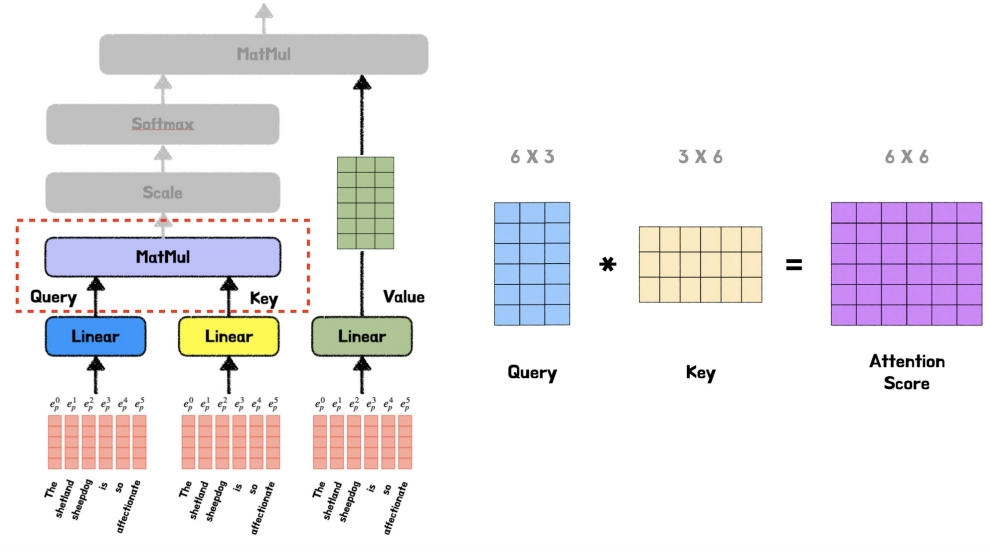

문제점  : Attention Score의 극단화 

#### Scaled Dot-Product Attention
기존의 Dot-Product Attention의 문제를 해결하고자, "Attention is All You Need"의 저자들이 제안한 현재 트랜스포머 방식의 표준    
→ Transformer의 “어텐션 계산 공식” 자체를 의미!

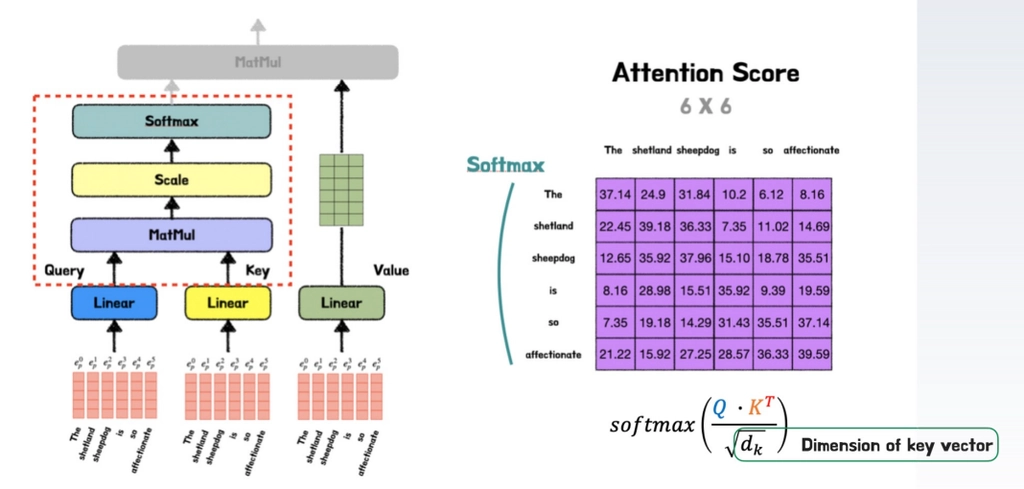

Scaled Dot-Product Attention 계산의 결과로 얻어지는 벡터    
- Cross-Attention : 현재 생성 중인 단어가, 입력 문장에서 어떤 단어들에 집중해야 하는지를 반영한 Context Vector
- Self-Attention : 문장 내 다른 단어들과의 관계를 반영한 문맥적 표현

## <span style="background-color:#F993C0; color:#311d26; padding:4px; border-radius:0px;"> Multi-Head Attention </span>

#### <span style="background-color:#633a4c; color:#fde9f2; padding:4px; border-radius:0px;"> Multi-Head Attention </span>

: 한 단어와 다른 단어 간의 관계를 여러 차원으로 나누어 병렬로 학습

- Attention is all you need 에서는 512차원의 입력 벡터를 64차원씩 8개의 벡터로 나누고, Attention 스코어를 병렬로 여러 번 계산 하는데, 이 과정이 Multi-Head Attention!

#### <span style="background-color:#633a4c; color:#fde9f2; padding:4px; border-radius:0px;"> Multi-Head Attention 작동 방식 </span>

1. 분할 (Projection) - 8명의 헤드에 단어 벡터 할당
2. 병렬 어텐션 계산 - 각 헤드들이 각자 분석 수행
3. 결합 및 최종 투영

## <span style="background-color:#F993C0; color:#311d26; padding:4px; border-radius:0px;"> Transformer 전체 아키텍처 </span>

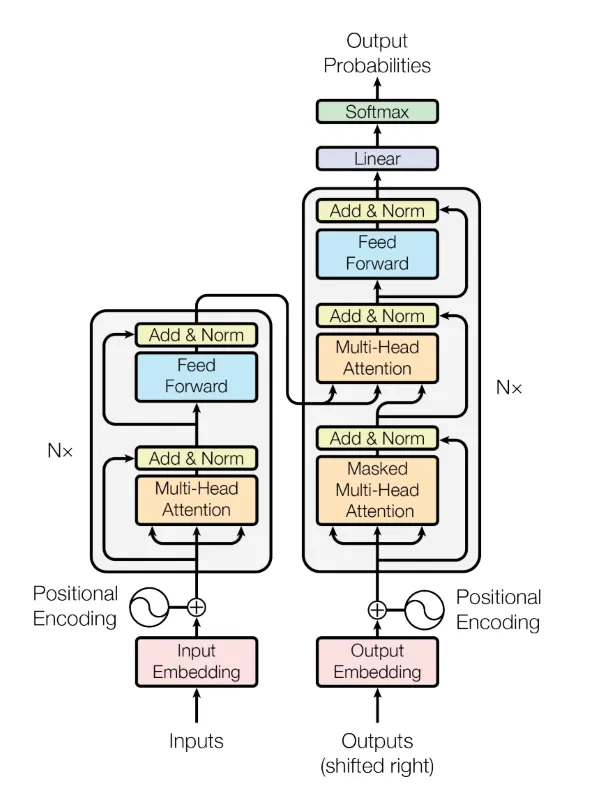

#### <span style="background-color:#633a4c; color:#fde9f2; padding:4px; border-radius:0px;"> 전처리 단계(토큰화 - 임베딩 - Positional Encoding)  </span>

1. 토큰화 (Tokenization)    
: 입력 텍스트를 모델이 처리할 수 있는 단위(tokens)로 나누는 첫 번째 단계

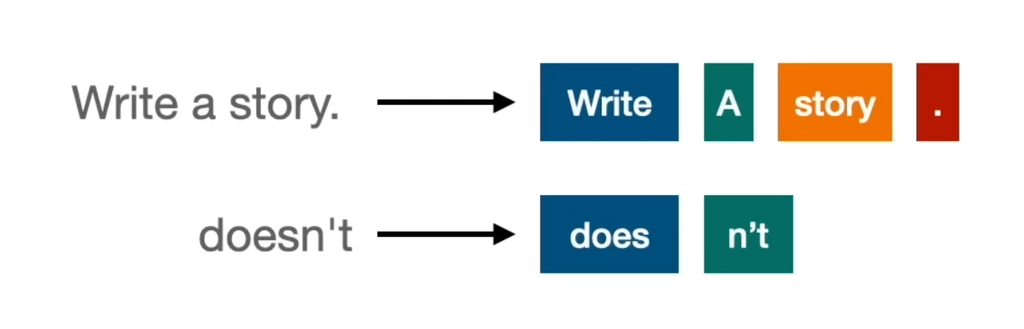

토큰화 방법
- 대부분의 경우 각 토큰은 하나의 단어에 해당. ex) Write, A, Story 
- 문장 부호 역시 별도의 토큰. ex) ., !
- 일부 단어는 하나 이상의 토큰으로 나뉠 수 있음. ex) doesn’t → does, n’t

2. 임베딩 (Embedding)   
: 토큰화된 각 단위(토큰)는 임베딩 단계에서 숫자의 벡터로 변환

- 의미적으로 유사한 단어들은 임베딩 공간에서 유사한 숫자(좌표)로 변환
- 이러한 유사성 덕분에, 임베딩은 단어의 문맥을 포착하고 단어 간의 관계를 파악하는 어텐션 메커니즘이 작동하기 전에 단어에 대한 기본적인 속성을 제공

3. Positional Encoding   
: Positional Encoding은 단어들의 순서 정보 를 임베딩 벡터에 추가하는 단계!

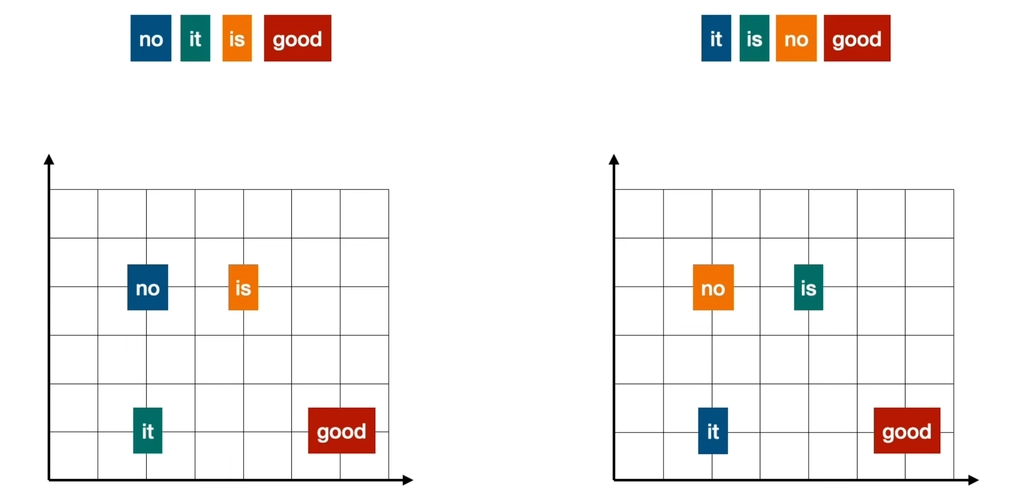

- 단어들은 문법적 측면이나, 문맥을 파악하기 위해서나 등장한 순서가 매우 중요하기 때문에, 이 순서 정보, 즉 위치 정보 를 제공하기 위해 positional encoding을 사용

#### <span style="background-color:#633a4c; color:#fde9f2; padding:4px; border-radius:0px;"> Encoder와 Decoder </span>

#### Encoder
: 입력 문장을 이해하고 요약된 의미 벡터로 변환하는 역할    
- 전처리 과정(토큰화, 임베딩, Positional Encoding) 및 인코더 레이어(Multi-Head Attention, Feed Forward Layer)로 구성되어 있음
- 다음 두 가지 주요 하위 레이어로 구성
    - Multi-Head Attention
    - Feed-Forward 


#### Decoder
: Encoder가 분석한 입력 문장의 의미 벡터를 받아서 출력 문장을 순차적으로 생성하는 역할    
- 전처리 과정, 디코더 레이어, 선형 레이어와 소프트맥스 레이어로 이루어져 있음
- 다음 세 가지 하위 레이어로 구성
    - Masked Multi-Head Attention
    - Encoder-Decoder Multi-Head Attention (Cross-Attention)
    - Feed-Forward Layer